# House Price Prediction



## 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

print("All libraries imported successfully")

All libraries imported successfully


## 2. Loading the Dataset

In [2]:
df = pd.read_csv(r'C:\Users\USSER\Desktop\House Price.csv')
print("Dataset loaded. Shape:", df.shape)

Dataset loaded. Shape: (29451, 12)


In [3]:
# looking at first few rows to understand the data
df.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


In [4]:
df.tail()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
29446,Owner,0,0,3,BHK,2500.000000,1,1,"Shamshabad Road,Agra",27.140626,78.043277,45.0
29447,Owner,0,0,2,BHK,769.230769,1,1,"E3-108, Lake View Recidency,,Vapi",39.945409,-86.150721,16.0
29448,Dealer,0,0,2,BHK,1022.641509,1,1,"Ajmer Road,Jaipur",26.928785,75.828002,27.1
29449,Owner,0,0,2,BHK,927.079009,1,1,"Sholinganallur,Chennai",12.900150,80.227910,67.0
29450,Dealer,0,1,2,BHK,896.774194,1,1,"Jagatpura,Jaipur",26.832353,75.841749,27.8


In [5]:
# checking the shape
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 29451
Columns: 12


So we have **29451 rows** and **12 columns** in our dataset.

## 3. Data Understanding & Exploration

In [6]:
# getting info about data types and null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29451 entries, 0 to 29450
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   POSTED_BY              29451 non-null  str    
 1   UNDER_CONSTRUCTION     29451 non-null  int64  
 2   RERA                   29451 non-null  int64  
 3   BHK_NO.                29451 non-null  int64  
 4   BHK_OR_RK              29451 non-null  str    
 5   SQUARE_FT              29451 non-null  float64
 6   READY_TO_MOVE          29451 non-null  int64  
 7   RESALE                 29451 non-null  int64  
 8   ADDRESS                29451 non-null  str    
 9   LONGITUDE              29451 non-null  float64
 10  LATITUDE               29451 non-null  float64
 11  TARGET(PRICE_IN_LACS)  29451 non-null  float64
dtypes: float64(4), int64(5), str(3)
memory usage: 3.5 MB


In [7]:
# checking for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
POSTED_BY                0
UNDER_CONSTRUCTION       0
RERA                     0
BHK_NO.                  0
BHK_OR_RK                0
SQUARE_FT                0
READY_TO_MOVE            0
RESALE                   0
ADDRESS                  0
LONGITUDE                0
LATITUDE                 0
TARGET(PRICE_IN_LACS)    0
dtype: int64


Good news — there are **no missing values** in the dataset. So we don't need to do any imputation.

In [8]:
# checking duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 401


In [9]:
# statistical summary of numerical columns
df.describe()

,UNDER_CONSTRUCTION,RERA,BHK_NO.,SQUARE_FT,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
count,29451.000000,29451.000000,29451.000000,2.945100e+04,29451.000000,29451.000000,29451.000000,29451.000000,29451.000000
mean,0.179756,0.317918,2.392279,1.980217e+04,0.820244,0.929578,21.300255,76.837695,142.898746
std,0.383991,0.465675,0.879091,1.901335e+06,0.383991,0.255861,6.205306,10.557747,656.880713
min,0.000000,0.000000,1.000000,3.000000e+00,0.000000,0.000000,-37.713008,-121.761248,0.250000
25%,0.000000,0.000000,2.000000,9.000211e+02,1.000000,1.000000,18.452663,73.798100,38.000000
50%,0.000000,0.000000,2.000000,1.175057e+03,1.000000,1.000000,20.750000,77.324137,62.000000
75%,0.000000,1.000000,3.000000,1.550688e+03,1.000000,1.000000,26.900926,77.828740,100.000000
max,1.000000,1.000000,20.000000,2.545455e+08,1.000000,1.000000,59.912884,152.962676,30000.000000


In [10]:
# statistical summary of categorical columns
df.describe(include='object')

,POSTED_BY,BHK_OR_RK,ADDRESS
count,29451,29451,29451
unique,3,2,6899
top,Dealer,BHK,"Zirakpur,Chandigarh"
freq,18291,29427,509


In [11]:
# lets see unique values in categorical columns
print("POSTED_BY unique values:", df['POSTED_BY'].unique())
print("BHK_OR_RK unique values:", df['BHK_OR_RK'].unique())
print("Number of unique addresses:", df['ADDRESS'].nunique())

POSTED_BY unique values: <ArrowStringArray>
['Owner', 'Dealer', 'Builder']
Length: 3, dtype: str
BHK_OR_RK unique values: <ArrowStringArray>
['BHK', 'RK']
Length: 2, dtype: str
Number of unique addresses: 6899


**Observations so far:**
- POSTED_BY has 3 categories: Owner, Dealer, Builder
- BHK_OR_RK has 2 categories: BHK and RK
- ADDRESS has way too many unique values (6899), so we might need to handle it differently
- SQUARE_FT has a very wide range which suggests there could be outliers

## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Variable Distribution

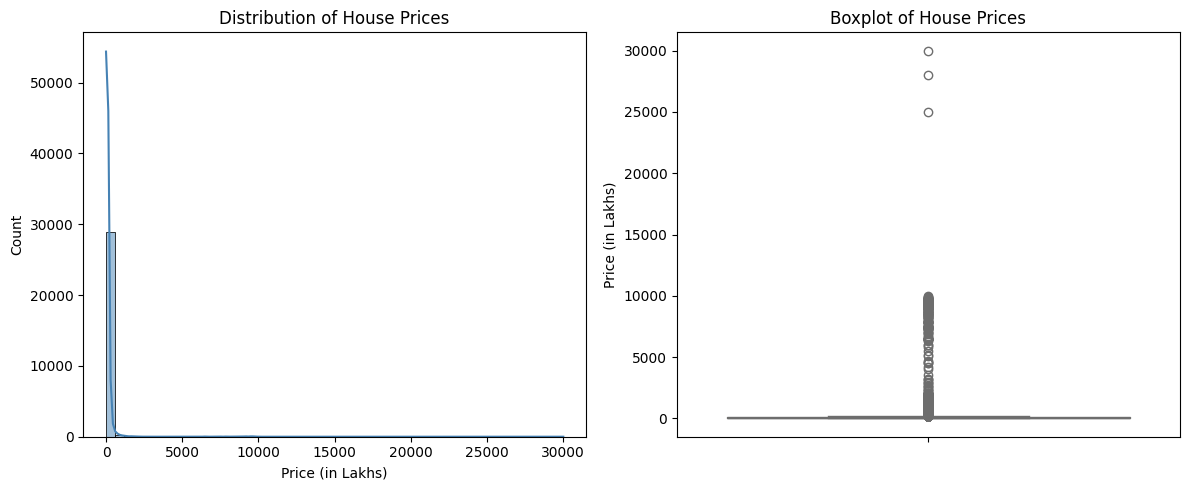

Skewness: 17.58
Kurtosis: 451.93


In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['TARGET(PRICE_IN_LACS)'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price (in Lakhs)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['TARGET(PRICE_IN_LACS)'], color='salmon')
plt.title('Boxplot of House Prices')
plt.ylabel('Price (in Lakhs)')

plt.tight_layout()
plt.show()

print(f"Skewness: {df['TARGET(PRICE_IN_LACS)'].skew():.2f}")
print(f"Kurtosis: {df['TARGET(PRICE_IN_LACS)'].kurtosis():.2f}")

The target variable is **highly right-skewed** (skewness ~ 17.58). Most houses are priced below 200 lakhs but there are some extremely expensive properties pushing the distribution to the right. We'll deal with the outliers later.

### 4.2 Categorical Features

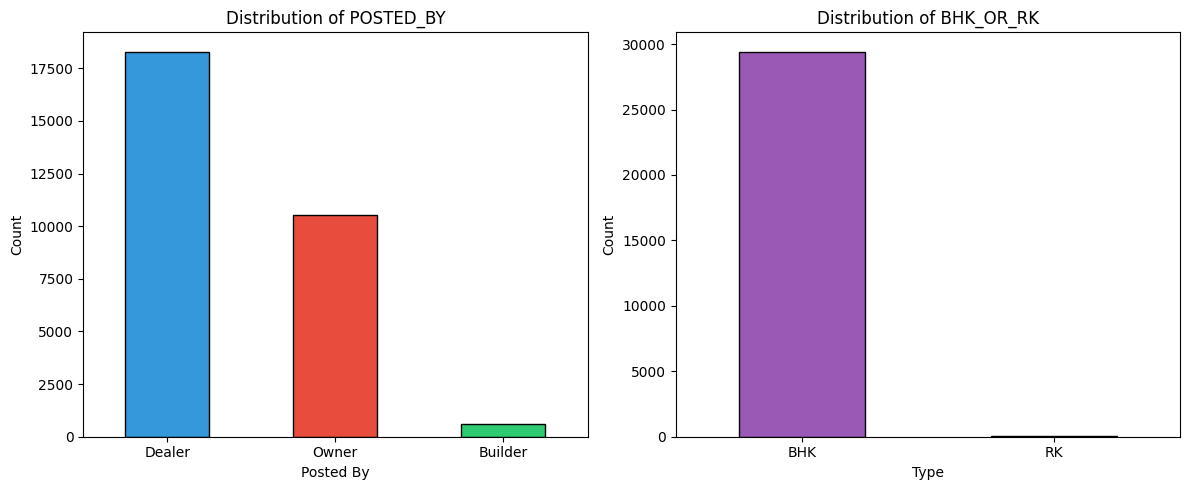

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# POSTED_BY distribution
df['POSTED_BY'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Distribution of POSTED_BY')
axes[0].set_xlabel('Posted By')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# BHK_OR_RK distribution
df['BHK_OR_RK'].value_counts().plot(kind='bar', ax=axes[1], color=['#9b59b6', '#f1c40f'], edgecolor='black')
axes[1].set_title('Distribution of BHK_OR_RK')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

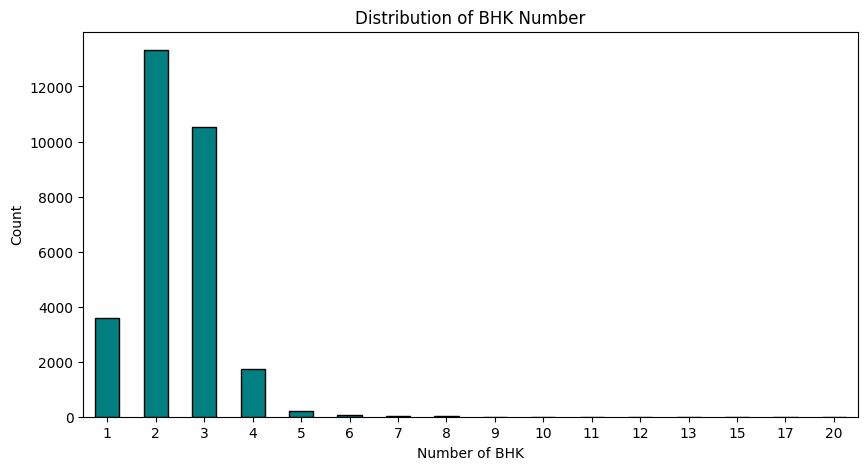

In [14]:
# BHK number distribution
plt.figure(figsize=(10, 5))
df['BHK_NO.'].value_counts().sort_index().plot(kind='bar', color='teal', edgecolor='black')
plt.title('Distribution of BHK Number')
plt.xlabel('Number of BHK')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

Most properties are **2 BHK** followed by 3 BHK. Properties with more than 5 BHK are very rare.

### 4.3 Binary Features

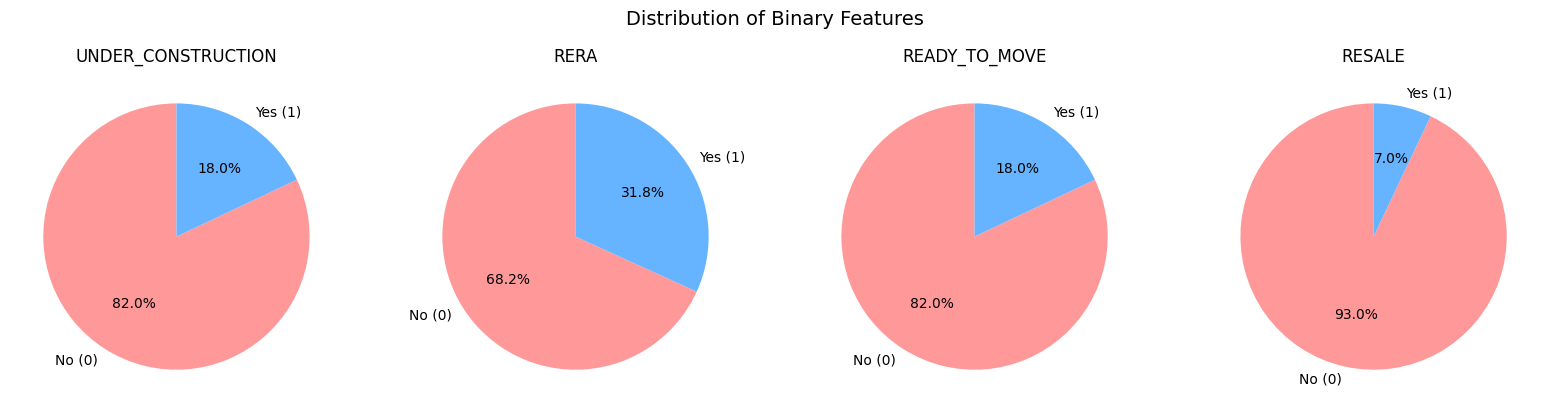

In [15]:
binary_cols = ['UNDER_CONSTRUCTION', 'RERA', 'READY_TO_MOVE', 'RESALE']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(binary_cols):
    counts = df[col].value_counts()
    axes[i].pie(counts, labels=['No (0)', 'Yes (1)'], autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'], startangle=90)
    axes[i].set_title(col)

plt.suptitle('Distribution of Binary Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

- Around **82%** of properties are not under construction
- About **68%** don't have RERA approval
- **82%** are ready to move (which makes sense since if it's not under construction, it should be ready)
- About **65%** are resale properties

### 4.4 SQUARE_FT Analysis

In [16]:
print("Square Feet statistics:")
print(f"Min: {df['SQUARE_FT'].min()}")
print(f"Max: {df['SQUARE_FT'].max()}")
print(f"Mean: {df['SQUARE_FT'].mean():.2f}")
print(f"Median: {df['SQUARE_FT'].median():.2f}")

Square Feet statistics:
Min: 3.0
Max: 254545454.5
Mean: 19802.17
Median: 1175.06


The max SQUARE_FT is **254545454.5** which is clearly an outlier (that's like 254 million sq ft, which is impossible for a residential property!). We need to handle these outliers.

### 4.5 Average Price by Categories

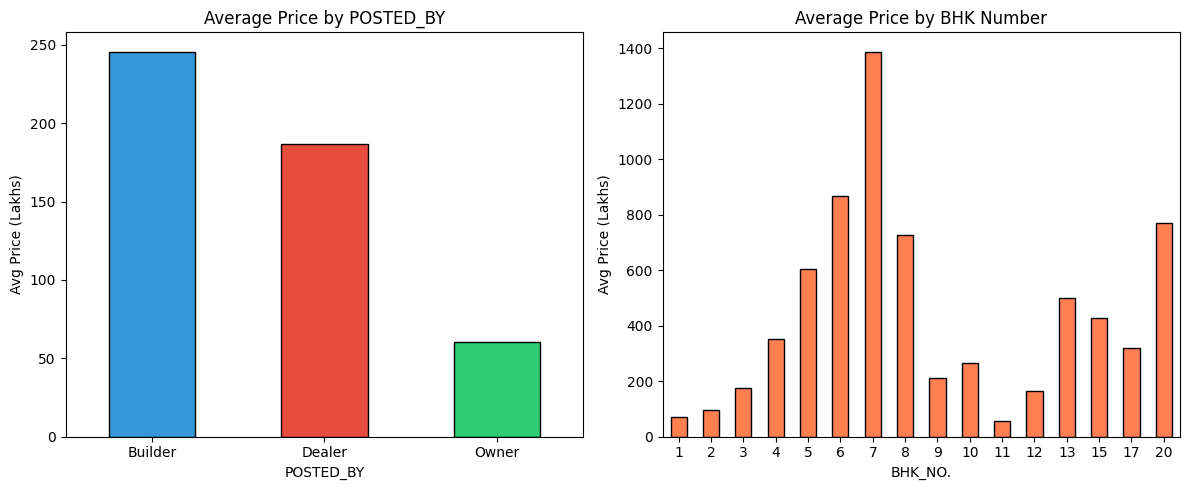

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# avg price by POSTED_BY
df.groupby('POSTED_BY')['TARGET(PRICE_IN_LACS)'].mean().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Average Price by POSTED_BY')
axes[0].set_ylabel('Avg Price (Lakhs)')
axes[0].tick_params(axis='x', rotation=0)

# avg price by BHK number
df.groupby('BHK_NO.')['TARGET(PRICE_IN_LACS)'].mean().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Average Price by BHK Number')
axes[1].set_ylabel('Avg Price (Lakhs)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

As expected, properties with more BHK tend to have higher prices. Builder-posted properties are generally pricier than dealer or owner postings.

### 4.6 Correlation Analysis

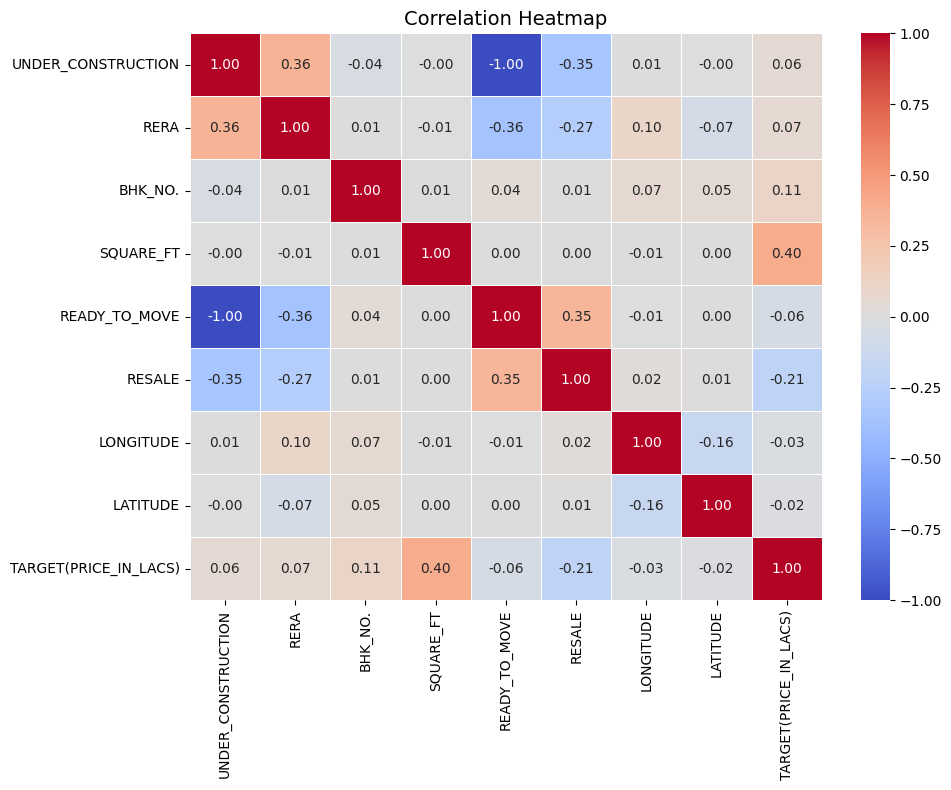

In [18]:
# correlation heatmap for numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
# lets check correlation with the target specifically
print("Correlation with Target (Price):")
print(corr_matrix['TARGET(PRICE_IN_LACS)'].sort_values(ascending=False))

Correlation with Target (Price):
TARGET(PRICE_IN_LACS)    1.000000
SQUARE_FT                0.402685
BHK_NO.                  0.112283
RERA                     0.067636
UNDER_CONSTRUCTION       0.055399
LATITUDE                -0.017254
LONGITUDE               -0.031112
READY_TO_MOVE           -0.055399
RESALE                  -0.207378
Name: TARGET(PRICE_IN_LACS), dtype: float64


**Key observations from correlation:**
- **SQUARE_FT** has the highest positive correlation (0.40) with price — bigger house = higher price, makes sense
- **RESALE** has a negative correlation (-0.21) — resale properties tend to be cheaper
- **BHK_NO** has a moderate positive correlation (0.11)
- UNDER_CONSTRUCTION and READY_TO_MOVE are perfectly inversely correlated (-1.00), which is logical

### 4.7 Scatter Plot - Square Feet vs Price

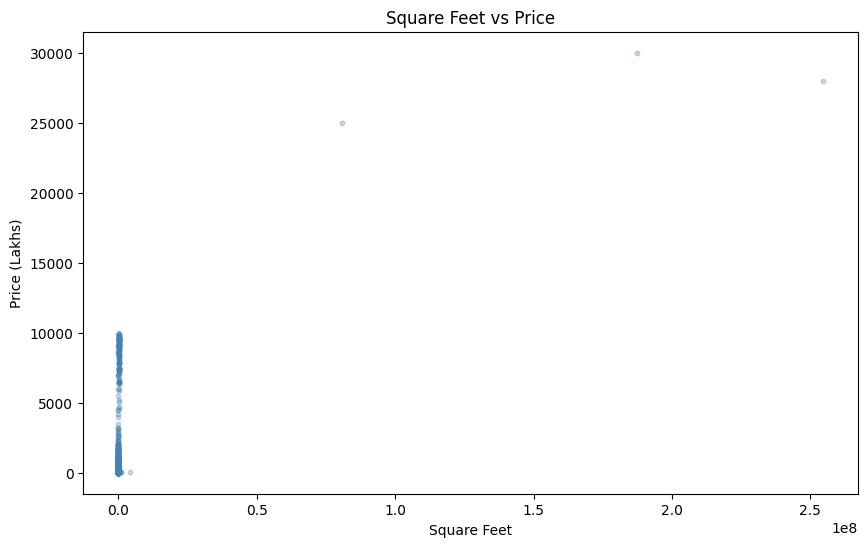

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(df['SQUARE_FT'], df['TARGET(PRICE_IN_LACS)'], alpha=0.3, s=10, color='steelblue')
plt.title('Square Feet vs Price')
plt.xlabel('Square Feet')
plt.ylabel('Price (Lakhs)')
plt.show()

We can clearly see there are extreme outliers in SQUARE_FT. Let's clean this up.

## 5. Data Preprocessing

### 5.1 Dropping the ADDRESS column

ADDRESS has 6899 unique values which is way too many to encode. Also the location info is somewhat captured by LONGITUDE and LATITUDE. So let's drop it.

In [21]:
# extracting city from address before dropping it (might be useful)
df['CITY'] = df['ADDRESS'].apply(lambda x: x.split(',')[-1].strip() if ',' in str(x) else x)
print("Top 10 cities:")
print(df['CITY'].value_counts().head(10))

Top 10 cities:
CITY
Bangalore      4340
Lalitpur       2993
Mumbai         2023
Pune           1991
Noida          1767
Kolkata        1709
Maharashtra    1579
Chennai        1255
Ghaziabad      1087
Jaipur          962
Name: count, dtype: int64


In [22]:
# now lets drop the ADDRESS column
df.drop('ADDRESS', axis=1, inplace=True)
print("ADDRESS column dropped.")
print("Shape now:", df.shape)

ADDRESS column dropped.
Shape now: (29451, 12)


### 5.2 Handling Outliers

We saw that SQUARE_FT and TARGET have some crazy outliers. Let's use the IQR method to remove them.

In [23]:
print(f"Shape before removing outliers: {df.shape}")

# removing outliers from SQUARE_FT using IQR
Q1 = df['SQUARE_FT'].quantile(0.25)
Q3 = df['SQUARE_FT'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"SQUARE_FT - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

df = df[(df['SQUARE_FT'] >= lower_bound) & (df['SQUARE_FT'] <= upper_bound)]
print(f"Shape after SQUARE_FT outlier removal: {df.shape}")

Shape before removing outliers: (29451, 12)
SQUARE_FT - Q1: 900.0211296, Q3: 1550.688124, IQR: 650.6669944
Lower bound: -75.97936200000004, Upper bound: 2526.6886156
Shape after SQUARE_FT outlier removal: (27816, 12)


In [24]:
# also removing extreme outliers from TARGET
Q1_t = df['TARGET(PRICE_IN_LACS)'].quantile(0.25)
Q3_t = df['TARGET(PRICE_IN_LACS)'].quantile(0.75)
IQR_t = Q3_t - Q1_t
lower_t = Q1_t - 1.5 * IQR_t
upper_t = Q3_t + 1.5 * IQR_t

print(f"TARGET - Lower bound: {lower_t}, Upper bound: {upper_t}")

df = df[(df['TARGET(PRICE_IN_LACS)'] >= lower_t) & (df['TARGET(PRICE_IN_LACS)'] <= upper_t)]
print(f"Shape after TARGET outlier removal: {df.shape}")

TARGET - Lower bound: -52.5, Upper bound: 183.5
Shape after TARGET outlier removal: (25698, 12)


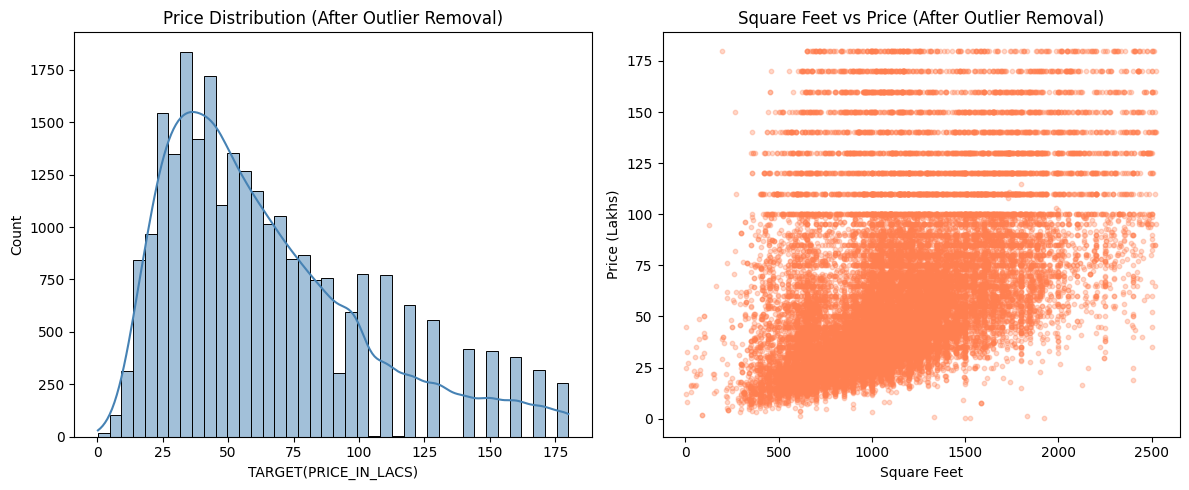

In [25]:
# let's visualize after outlier removal
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['TARGET(PRICE_IN_LACS)'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Price Distribution (After Outlier Removal)')

axes[1].scatter(df['SQUARE_FT'], df['TARGET(PRICE_IN_LACS)'], alpha=0.3, s=10, color='coral')
axes[1].set_title('Square Feet vs Price (After Outlier Removal)')
axes[1].set_xlabel('Square Feet')
axes[1].set_ylabel('Price (Lakhs)')

plt.tight_layout()
plt.show()

Much better! The data looks more reasonable now.

### 5.3 Dropping one of the perfectly correlated columns

UNDER_CONSTRUCTION and READY_TO_MOVE have a perfect negative correlation (-1). They are basically the opposite of each other. Keeping both will cause multicollinearity. Let's drop UNDER_CONSTRUCTION.

In [26]:
df.drop('UNDER_CONSTRUCTION', axis=1, inplace=True)
print("Dropped UNDER_CONSTRUCTION column")
print("Remaining columns:", list(df.columns))

Dropped UNDER_CONSTRUCTION column
Remaining columns: ['POSTED_BY', 'RERA', 'BHK_NO.', 'BHK_OR_RK', 'SQUARE_FT', 'READY_TO_MOVE', 'RESALE', 'LONGITUDE', 'LATITUDE', 'TARGET(PRICE_IN_LACS)', 'CITY']


### 5.4 Encoding Categorical Variables

We need to convert POSTED_BY, BHK_OR_RK, and CITY to numerical values since ML models need numbers.

In [27]:
le_posted = LabelEncoder()
le_bhk_rk = LabelEncoder()
le_city = LabelEncoder()

df['POSTED_BY'] = le_posted.fit_transform(df['POSTED_BY'])
df['BHK_OR_RK'] = le_bhk_rk.fit_transform(df['BHK_OR_RK'])
df['CITY'] = le_city.fit_transform(df['CITY'])

print("Encoding done!")
print("\nPOSTED_BY mapping:", dict(zip(le_posted.classes_, le_posted.transform(le_posted.classes_))))
print("BHK_OR_RK mapping:", dict(zip(le_bhk_rk.classes_, le_bhk_rk.transform(le_bhk_rk.classes_))))

Encoding done!

POSTED_BY mapping: {'Builder': 0, 'Dealer': 1, 'Owner': 2}
BHK_OR_RK mapping: {'BHK': 0, 'RK': 1}


In [28]:
# check the final dataset
df.head()

,POSTED_BY,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS),CITY
0,2,0,2,0,1300.236407,1,1,12.969910,77.597960,55.0,21
1,1,0,2,0,1275.000000,1,1,12.274538,76.644605,51.0,156
2,2,0,2,0,933.159722,1,1,12.778033,77.632191,43.0,21
3,2,1,2,0,929.921143,1,1,28.642300,77.344500,62.5,75
4,1,0,2,0,999.009247,0,1,22.592200,88.484911,60.5,130


In [29]:
# final check - all columns should be numeric now
print(df.dtypes)

POSTED_BY                  int32
RERA                       int64
BHK_NO.                    int64
BHK_OR_RK                  int32
SQUARE_FT                float64
READY_TO_MOVE              int64
RESALE                     int64
LONGITUDE                float64
LATITUDE                 float64
TARGET(PRICE_IN_LACS)    float64
CITY                       int32
dtype: object


## 6. Feature Selection & Train-Test Split

In [30]:
# separating features and target
X = df.drop('TARGET(PRICE_IN_LACS)', axis=1)
y = df['TARGET(PRICE_IN_LACS)']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", list(X.columns))

Features shape: (25698, 10)
Target shape: (25698,)

Feature columns: ['POSTED_BY', 'RERA', 'BHK_NO.', 'BHK_OR_RK', 'SQUARE_FT', 'READY_TO_MOVE', 'RESALE', 'LONGITUDE', 'LATITUDE', 'CITY']


In [31]:
# splitting into train and test (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 20558
Testing set size: 5140


### 6.1 Feature Scaling

Scaling the features so that all features are on the same scale. This helps especially with Linear Regression, KNN, and SVR.

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling done!")

Feature scaling done!


## 7. Model Building

We'll try multiple regression models and compare their performance:
1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Decision Tree Regressor
5. Random Forest Regressor
6. Gradient Boosting Regressor
7. AdaBoost Regressor
8. XGBoost Regressor
9. K-Nearest Neighbors (KNN)
10. Support Vector Regressor (SVR)

Let's see which one works best for this data!

### 7.1 Linear Regression

In [33]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# predictions
lr_train_pred = lr_model.predict(X_train_scaled)
lr_test_pred = lr_model.predict(X_test_scaled)

print("=== Linear Regression Results ===")
print(f"\nTraining R2 Score: {r2_score(y_train, lr_train_pred):.4f}")
print(f"Testing R2 Score:  {r2_score(y_test, lr_test_pred):.4f}")
print(f"\nMAE:  {mean_absolute_error(y_test, lr_test_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_test_pred)):.4f}")

=== Linear Regression Results ===

Training R2 Score: 0.3222
Testing R2 Score:  0.3190

MAE:  24.0097
RMSE: 31.7469


### 7.2 Ridge Regression

Ridge is like Linear Regression but with L2 regularization. It helps when there is multicollinearity.

In [34]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

ridge_train_pred = ridge_model.predict(X_train_scaled)
ridge_test_pred = ridge_model.predict(X_test_scaled)

print("=== Ridge Regression Results ===")
print(f"\nTraining R2 Score: {r2_score(y_train, ridge_train_pred):.4f}")
print(f"Testing R2 Score:  {r2_score(y_test, ridge_test_pred):.4f}")
print(f"\nMAE:  {mean_absolute_error(y_test, ridge_test_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, ridge_test_pred)):.4f}")

=== Ridge Regression Results ===

Training R2 Score: 0.3222
Testing R2 Score:  0.3190

MAE:  24.0098
RMSE: 31.7469


### 7.3 Lasso Regression

Lasso uses L1 regularization which can also do feature selection by making some coefficients zero.

In [35]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)

lasso_train_pred = lasso_model.predict(X_train_scaled)
lasso_test_pred = lasso_model.predict(X_test_scaled)

print("=== Lasso Regression Results ===")
print(f"\nTraining R2 Score: {r2_score(y_train, lasso_train_pred):.4f}")
print(f"Testing R2 Score:  {r2_score(y_test, lasso_test_pred):.4f}")
print(f"\nMAE:  {mean_absolute_error(y_test, lasso_test_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lasso_test_pred)):.4f}")

=== Lasso Regression Results ===

Training R2 Score: 0.3221
Testing R2 Score:  0.3191

MAE:  24.0065
RMSE: 31.7457


### 7.4 Decision Tree Regressor

In [36]:
dt_model = DecisionTreeRegressor(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)  # decision tree doesnt need scaling

# predictions
dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)

print("=== Decision Tree Results ===")
print(f"\nTraining R2 Score: {r2_score(y_train, dt_train_pred):.4f}")
print(f"Testing R2 Score:  {r2_score(y_test, dt_test_pred):.4f}")
print(f"\nMAE:  {mean_absolute_error(y_test, dt_test_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, dt_test_pred)):.4f}")

=== Decision Tree Results ===

Training R2 Score: 0.7690
Testing R2 Score:  0.6750

MAE:  15.0180
RMSE: 21.9326


### 7.5 Random Forest Regressor

In [37]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=12, n_jobs=-1)
rf_model.fit(X_train, y_train)  # no scaling needed for tree-based models

# predictions
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

print("=== Random Forest Results ===")
print(f"\nTraining R2 Score: {r2_score(y_train, rf_train_pred):.4f}")
print(f"Testing R2 Score:  {r2_score(y_test, rf_test_pred):.4f}")
print(f"\nMAE:  {mean_absolute_error(y_test, rf_test_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_test_pred)):.4f}")

=== Random Forest Results ===

Training R2 Score: 0.8562
Testing R2 Score:  0.7431

MAE:  13.3064
RMSE: 19.5004


### 7.6 Gradient Boosting Regressor

Gradient Boosting builds trees sequentially where each new tree tries to fix the mistakes of the previous one.

In [38]:
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

gb_train_pred = gb_model.predict(X_train)
gb_test_pred = gb_model.predict(X_test)

print("=== Gradient Boosting Results ===")
print(f"\nTraining R2 Score: {r2_score(y_train, gb_train_pred):.4f}")
print(f"Testing R2 Score:  {r2_score(y_test, gb_test_pred):.4f}")
print(f"\nMAE:  {mean_absolute_error(y_test, gb_test_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, gb_test_pred)):.4f}")

=== Gradient Boosting Results ===

Training R2 Score: 0.7646
Testing R2 Score:  0.7290

MAE:  14.0476
RMSE: 20.0264


### 7.7 AdaBoost Regressor

AdaBoost is another boosting technique. It gives more weight to the data points that are harder to predict.

In [39]:
ada_model = AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
ada_model.fit(X_train, y_train)

ada_train_pred = ada_model.predict(X_train)
ada_test_pred = ada_model.predict(X_test)

print("=== AdaBoost Results ===")
print(f"\nTraining R2 Score: {r2_score(y_train, ada_train_pred):.4f}")
print(f"Testing R2 Score:  {r2_score(y_test, ada_test_pred):.4f}")
print(f"\nMAE:  {mean_absolute_error(y_test, ada_test_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, ada_test_pred)):.4f}")

=== AdaBoost Results ===

Training R2 Score: 0.4457
Testing R2 Score:  0.4326

MAE:  23.2915
RMSE: 28.9788


### 7.8 XGBoost Regressor

XGBoost is one of the most popular and powerful algorithms out there. Its an optimized version of gradient boosting.

In [40]:
xgb_model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)

xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

print("=== XGBoost Results ===")
print(f"\nTraining R2 Score: {r2_score(y_train, xgb_train_pred):.4f}")
print(f"Testing R2 Score:  {r2_score(y_test, xgb_test_pred):.4f}")
print(f"\nMAE:  {mean_absolute_error(y_test, xgb_test_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, xgb_test_pred)):.4f}")

=== XGBoost Results ===

Training R2 Score: 0.7919
Testing R2 Score:  0.7444

MAE:  13.5641
RMSE: 19.4497


### 7.9 K-Nearest Neighbors (KNN) Regressor

KNN predicts based on the average of k nearest neighbors. It needs scaled data since it uses distance.

In [41]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)  # KNN needs scaled data

knn_train_pred = knn_model.predict(X_train_scaled)
knn_test_pred = knn_model.predict(X_test_scaled)

print("=== KNN Regressor Results ===")
print(f"\nTraining R2 Score: {r2_score(y_train, knn_train_pred):.4f}")
print(f"Testing R2 Score:  {r2_score(y_test, knn_test_pred):.4f}")
print(f"\nMAE:  {mean_absolute_error(y_test, knn_test_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, knn_test_pred)):.4f}")

=== KNN Regressor Results ===

Training R2 Score: 0.7442
Testing R2 Score:  0.6146

MAE:  16.6355
RMSE: 23.8842


### 7.10 Support Vector Regressor (SVR)

SVR uses support vector machines for regression. We'll use RBF kernel. Note: SVR can be slow on large datasets so we are using it on scaled features.

In [42]:
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)

svr_train_pred = svr_model.predict(X_train_scaled)
svr_test_pred = svr_model.predict(X_test_scaled)

print("=== SVR Results ===")
print(f"\nTraining R2 Score: {r2_score(y_train, svr_train_pred):.4f}")
print(f"Testing R2 Score:  {r2_score(y_test, svr_test_pred):.4f}")
print(f"\nMAE:  {mean_absolute_error(y_test, svr_test_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, svr_test_pred)):.4f}")

=== SVR Results ===

Training R2 Score: 0.5856
Testing R2 Score:  0.5747

MAE:  17.3009
RMSE: 25.0899


## 8. Model Comparison

Now lets put all the results together and see which model performed the best.

In [43]:
# creating a comparison dataframe with all 10 models
model_names = ['Linear Regression', 'Ridge Regression', 'Lasso Regression',
               'Decision Tree', 'Random Forest', 'Gradient Boosting',
               'AdaBoost', 'XGBoost', 'KNN', 'SVR']

train_preds = [lr_train_pred, ridge_train_pred, lasso_train_pred,
               dt_train_pred, rf_train_pred, gb_train_pred,
               ada_train_pred, xgb_train_pred, knn_train_pred, svr_train_pred]

test_preds = [lr_test_pred, ridge_test_pred, lasso_test_pred,
              dt_test_pred, rf_test_pred, gb_test_pred,
              ada_test_pred, xgb_test_pred, knn_test_pred, svr_test_pred]

results = pd.DataFrame({
    'Model': model_names,
    'Train R2': [r2_score(y_train, p) for p in train_preds],
    'Test R2': [r2_score(y_test, p) for p in test_preds],
    'MAE': [mean_absolute_error(y_test, p) for p in test_preds],
    'RMSE': [np.sqrt(mean_squared_error(y_test, p)) for p in test_preds]
})

results = results.sort_values('Test R2', ascending=False).reset_index(drop=True)
results = results.round(4)
print(results.to_string(index=False))

            Model  Train R2  Test R2     MAE    RMSE
          XGBoost    0.7919   0.7444 13.5641 19.4497
    Random Forest    0.8562   0.7431 13.3064 19.5004
Gradient Boosting    0.7646   0.7290 14.0476 20.0264
    Decision Tree    0.7690   0.6750 15.0180 21.9326
              KNN    0.7442   0.6146 16.6355 23.8842
              SVR    0.5856   0.5747 17.3009 25.0899
         AdaBoost    0.4457   0.4326 23.2915 28.9788
 Lasso Regression    0.3221   0.3191 24.0065 31.7457
Linear Regression    0.3222   0.3190 24.0097 31.7469
 Ridge Regression    0.3222   0.3190 24.0098 31.7469


In [44]:
# let's find the best model
best_model_name = results.iloc[0]['Model']
best_r2 = results.iloc[0]['Test R2']
print(f"\nBest Model: {best_model_name} with Test R2 = {best_r2}")


Best Model: XGBoost with Test R2 = 0.7444


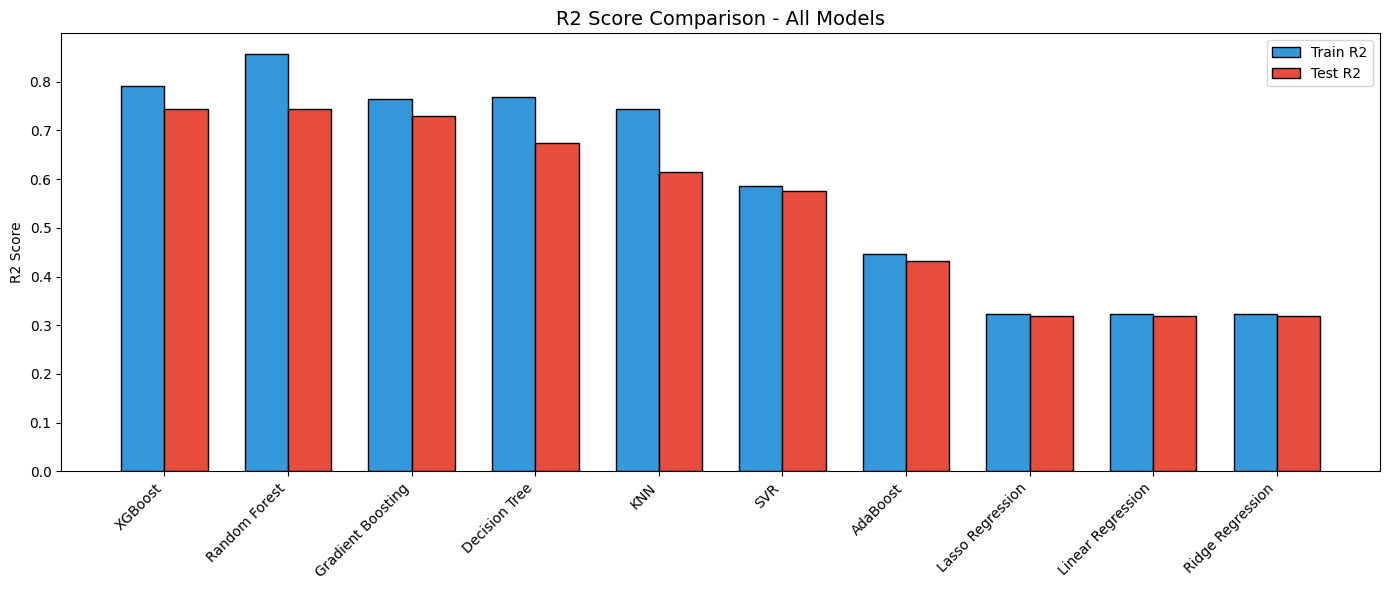

In [45]:
# visualizing R2 scores of all models
plt.figure(figsize=(14, 6))

x_pos = np.arange(len(results['Model']))
width = 0.35

plt.bar(x_pos - width/2, results['Train R2'], width, label='Train R2', color='#3498db', edgecolor='black')
plt.bar(x_pos + width/2, results['Test R2'], width, label='Test R2', color='#e74c3c', edgecolor='black')
plt.xticks(x_pos, results['Model'], rotation=45, ha='right')
plt.title('R2 Score Comparison - All Models', fontsize=14)
plt.ylabel('R2 Score')
plt.legend()
plt.tight_layout()
plt.show()

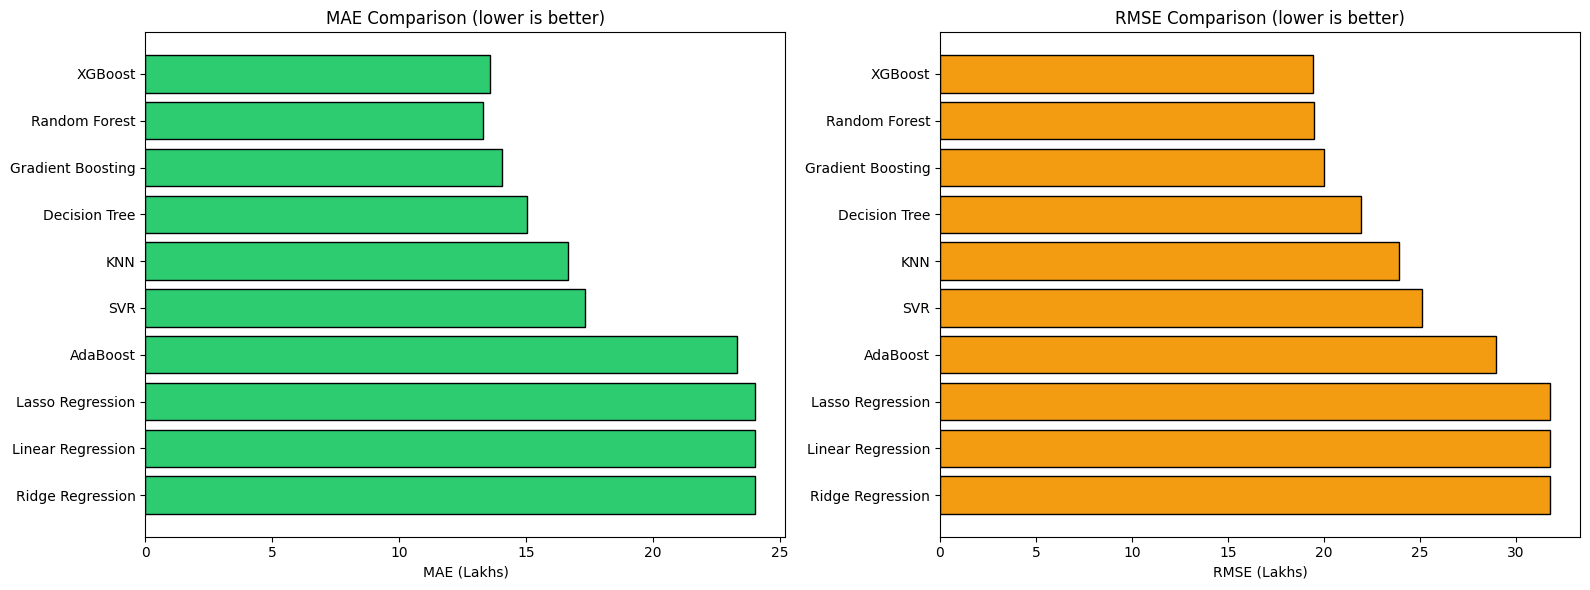

In [46]:
# MAE and RMSE comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MAE
axes[0].barh(results['Model'], results['MAE'], color='#2ecc71', edgecolor='black')
axes[0].set_title('MAE Comparison (lower is better)', fontsize=12)
axes[0].set_xlabel('MAE (Lakhs)')
axes[0].invert_yaxis()

# RMSE
axes[1].barh(results['Model'], results['RMSE'], color='#f39c12', edgecolor='black')
axes[1].set_title('RMSE Comparison (lower is better)', fontsize=12)
axes[1].set_xlabel('RMSE (Lakhs)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Feature Importance

Let's check feature importance from different tree-based models.

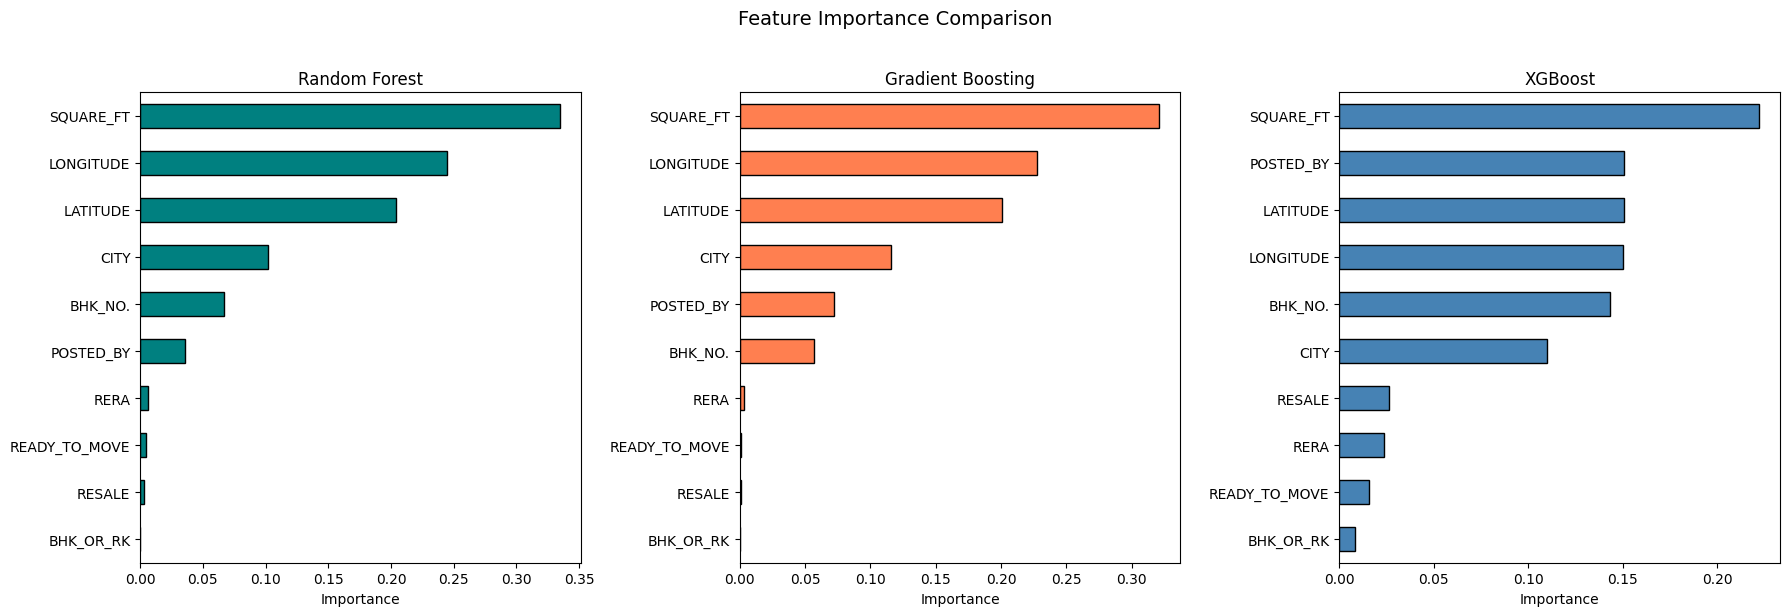

In [47]:
# comparing feature importance from multiple models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Random Forest
feat_rf = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_rf.plot(kind='barh', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Random Forest')
axes[0].set_xlabel('Importance')

# Gradient Boosting
feat_gb = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_gb.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Gradient Boosting')
axes[1].set_xlabel('Importance')

# XGBoost
feat_xgb = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_xgb.plot(kind='barh', ax=axes[2], color='steelblue', edgecolor='black')
axes[2].set_title('XGBoost')
axes[2].set_xlabel('Importance')

plt.suptitle('Feature Importance Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**SQUARE_FT** is consistently the most important feature across all models for predicting house prices, followed by CITY and LATITUDE/LONGITUDE. This makes total sense since the size and location of a property are the biggest factors in determining its price.

## 10. Actual vs Predicted (Best Model)

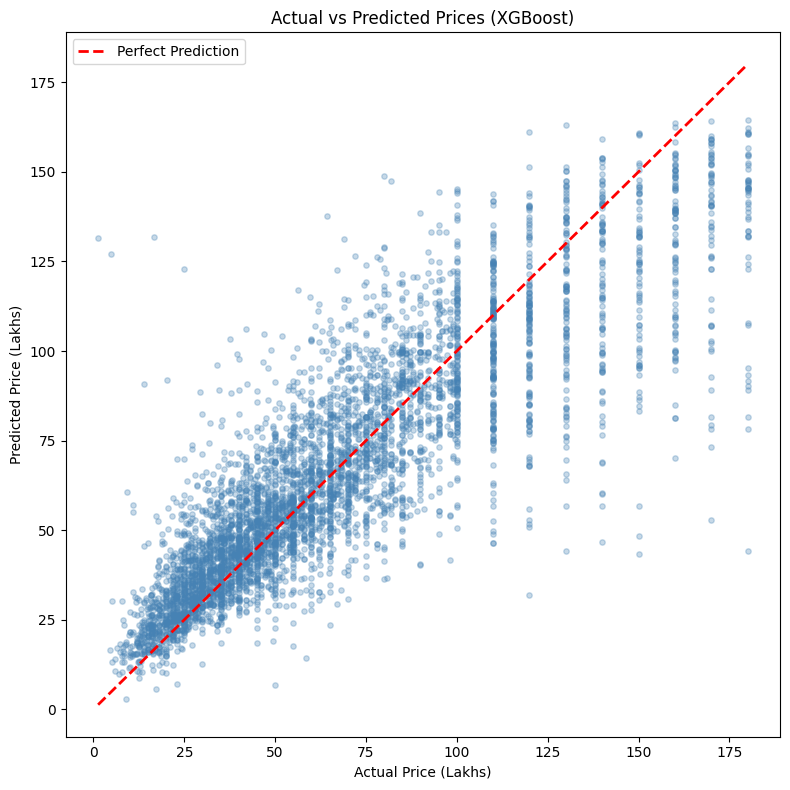

In [48]:
# mapping model names to their test predictions
pred_map = {
    'Linear Regression': lr_test_pred, 'Ridge Regression': ridge_test_pred,
    'Lasso Regression': lasso_test_pred, 'Decision Tree': dt_test_pred,
    'Random Forest': rf_test_pred, 'Gradient Boosting': gb_test_pred,
    'AdaBoost': ada_test_pred, 'XGBoost': xgb_test_pred,
    'KNN': knn_test_pred, 'SVR': svr_test_pred
}

best_pred = pred_map[best_model_name]

plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_pred, alpha=0.3, s=15, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Actual vs Predicted Prices ({best_model_name})')
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Residual Analysis

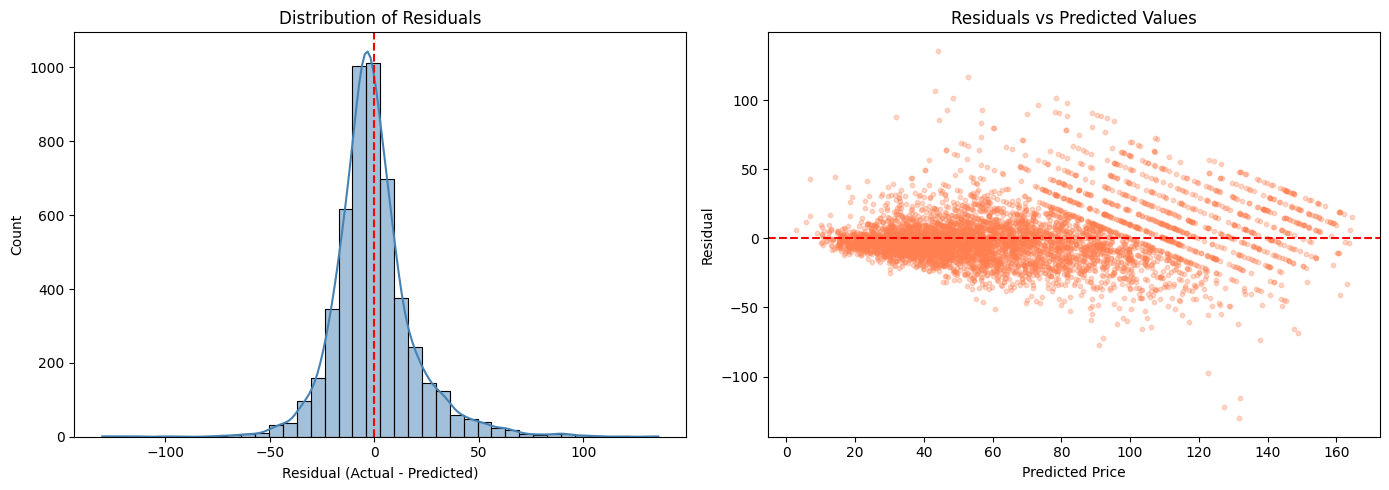

In [49]:
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# residual distribution
sns.histplot(residuals, bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_title('Distribution of Residuals')
axes[0].set_xlabel('Residual (Actual - Predicted)')

# residual vs predicted
axes[1].scatter(best_pred, residuals, alpha=0.3, s=10, color='coral')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted Values')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

The residuals are centered around 0 which is good. It means our model is not systematically over or under-predicting.

In [51]:
import joblib
joblib.dump(rf_model, 'house_price_rf_model.pkl')
joblib.dump(scaler, 'house_price_scaler.pkl')

['house_price_scaler.pkl']